In [44]:
import requests
import pandas as pd
import numpy as np
import json
import os
from dotenv import load_dotenv


In [45]:
load_dotenv()
# 1. API 설정
api_key = os.getenv('DATA_GO_KR_API_KEY')
url = "http://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty"

params = {
    'serviceKey':api_key,
    'returnType':'json',
    'numOfRows':'100',
    'pageNo':'1',
    'sidoName':'서울',
    'ver':'1.0',
}

# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)
data = json.loads(response.text)
# 3. DataFrame으로 변환
items = data['response']['body']['items']
df = pd.DataFrame(items)
df.to_csv('pm.csv', encoding='utf-8-sig')
df.head()

,so2Grade,coFlag,khaiValue,so2Value,coValue,pm25Flag,pm10Flag,o3Grade,pm10Value,khaiGrade,...,no2Grade,o3Flag,pm25Grade,so2Flag,dataTime,coGrade,no2Value,stationName,pm10Grade,o3Value
0,1,None,-,0.002,0.5,None,None,2,39,None,...,1,None,None,None,2026-03-06 15:00,1,0.012,중구,None,0.043
1,1,None,61,0.002,0.6,None,None,2,41,2,...,1,None,2,None,2026-03-06 15:00,1,0.016,한강대로,2,0.040
2,1,None,92,0.002,0.6,None,None,2,38,2,...,1,None,2,None,2026-03-06 15:00,1,0.014,종로구,2,0.041
3,1,None,82,0.002,0.6,None,None,2,47,2,...,1,None,2,None,2026-03-06 15:00,1,0.016,청계천로,2,0.037
4,1,None,82,0.002,0.6,None,None,2,43,2,...,1,None,2,None,2026-03-06 15:00,1,0.015,종로,2,0.044


In [11]:
import pprint
pprint.pprint(data)

{'response': {'body': {'items': [{'coFlag': None,
                                  'coGrade': '1',
                                  'coValue': '0.5',
                                  'dataTime': '2026-03-06 14:00',
                                  'khaiGrade': '2',
                                  'khaiValue': '82',
                                  'no2Flag': None,
                                  'no2Grade': '1',
                                  'no2Value': '0.021',
                                  'o3Flag': None,
                                  'o3Grade': '2',
                                  'o3Value': '0.033',
                                  'pm10Flag': None,
                                  'pm10Grade': '2',
                                  'pm10Value': '35',
                                  'pm25Flag': None,
                                  'pm25Grade': '2',
                                  'pm25Value': '25',
                                  'sidoName': '서울',


In [14]:
df.shape

(40, 23)

In [15]:
df.head()

,so2Grade,coFlag,khaiValue,so2Value,coValue,pm25Flag,pm10Flag,o3Grade,pm10Value,khaiGrade,...,no2Grade,o3Flag,pm25Grade,so2Flag,dataTime,coGrade,no2Value,stationName,pm10Grade,o3Value
0,None,통신장애,-,-,-,통신장애,통신장애,None,-,None,...,None,통신장애,None,통신장애,2026-03-06 14:00,None,-,중구,None,-
1,1,None,61,0.002,0.5,None,None,2,43,2,...,1,None,2,None,2026-03-06 14:00,1,0.018,한강대로,2,0.037
2,1,None,90,0.002,0.5,None,None,2,39,2,...,1,None,2,None,2026-03-06 14:00,1,0.015,종로구,2,0.037
3,1,None,85,0.002,0.5,None,None,2,42,2,...,1,None,2,None,2026-03-06 14:00,1,0.020,청계천로,2,0.033
4,1,None,82,0.002,0.5,None,None,2,41,2,...,1,None,2,None,2026-03-06 14:00,1,0.015,종로,2,0.040


In [72]:
import numpy as np
df = pd.read_csv('pm.csv').drop(columns=['Unnamed: 0'])
# 1. 필요한 컬럼만 추출 (측정일시, 측정소명, 미세먼지, 초미세먼지)
df = df[['dataTime', 'stationName', 'pm10Value', 'pm25Value']]

# 2. 데이터 타입 변환 (문자열 -> 숫자형 및 날짜형)
# API에서 통신 오류 등으로 '-' 문자가 들어오는 경우가 있어 NaN으로 변환
# raise	오류 발생 (기본값) , ignore	변환 안 하고 그대로 둠 , coerce	NaN으로 변환

# 2-1. 측정일시를 날짜형(datetime)으로 변환
df['dataTime'] = pd.to_datetime(df['dataTime'])

# 2-2. 미세먼지(pm10), 초미세먼지(pm25)를 숫자형으로 변환
# errors='coerce'를 쓰면 '--' 같은 문자가 NaN(결측치)으로 자동 변환됩니다.
df['pm10Value'] = pd.to_numeric(df['pm10Value'], errors='coerce')
df['pm25Value'] = pd.to_numeric(df['pm25Value'], errors='coerce')

# 3. 결측치 처리 (여기서는 단순 제거)
# df = df.dropna(subset=['pm10Value', 'pm25Value'])
df = df.dropna()

# 4. 특성 공학 (Feature Engineering)
# 4-1. 장소별, 요일, 월 파생 변수 생성
df['hour'] = df['dataTime'].dt.hour
df['day_of_week'] = df['dataTime'].dt.day_name()
df['month'] = df['dataTime'].dt.month

# 4-2. 미세먼지(PM10) 등급화 (한국 환경부 기준)
# 0~30: 좋음, 31~80: 보통, 81~150: 나쁨, 151~: 매우나쁨

# 등급을 나눌 기준 범위를 설정 (0~30, 31~80, 81~150, 151~무한대)
conditions = [
    (df['pm10Value'] <= 30),
    (df['pm10Value'] > 30) & (df['pm10Value'] <= 80),
    (df['pm10Value'] > 80) & (df['pm10Value'] <= 150),
    (df['pm10Value'] > 150)
]
choices = ['좋음', '보통', '나쁨', '매우나쁨']
df['pm10_grade'] = np.select(conditions, choices, default='알수없음')

df.head()

,dataTime,stationName,pm10Value,pm25Value,hour,day_of_week,month,pm10_grade
0,2026-03-06 15:00:00,중구,39.0,31.0,15,Friday,3,보통
1,2026-03-06 15:00:00,한강대로,41.0,36.0,15,Friday,3,보통
2,2026-03-06 15:00:00,종로구,38.0,35.0,15,Friday,3,보통
3,2026-03-06 15:00:00,청계천로,47.0,33.0,15,Friday,3,보통
4,2026-03-06 15:00:00,종로,43.0,32.0,15,Friday,3,보통


,dataTime,stationName,pm10Value,pm25Value,hour,day_of_week,month,pm10_grade
0,2026-03-06 15:00:00,중구,39.0,31.0,15,Friday,3,보통
1,2026-03-06 15:00:00,한강대로,41.0,36.0,15,Friday,3,보통
2,2026-03-06 15:00:00,종로구,38.0,35.0,15,Friday,3,보통
3,2026-03-06 15:00:00,청계천로,47.0,33.0,15,Friday,3,보통
4,2026-03-06 15:00:00,종로,43.0,32.0,15,Friday,3,보통
5,2026-03-06 15:00:00,용산구,43.0,35.0,15,Friday,3,보통
6,2026-03-06 15:00:00,광진구,40.0,28.0,15,Friday,3,보통
7,2026-03-06 15:00:00,성동구,40.0,26.0,15,Friday,3,보통
8,2026-03-06 15:00:00,강변북로,56.0,37.0,15,Friday,3,보통
9,2026-03-06 15:00:00,중랑구,35.0,30.0,15,Friday,3,보통


- 시각화

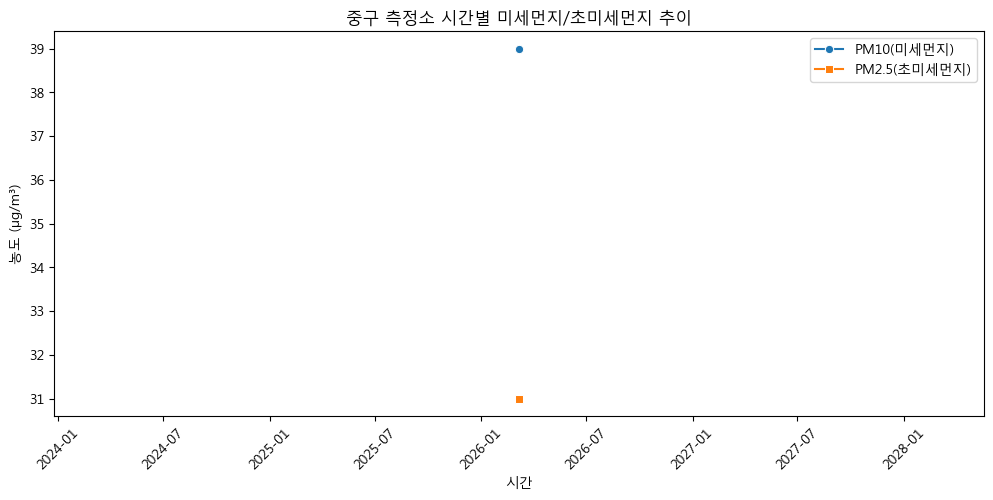

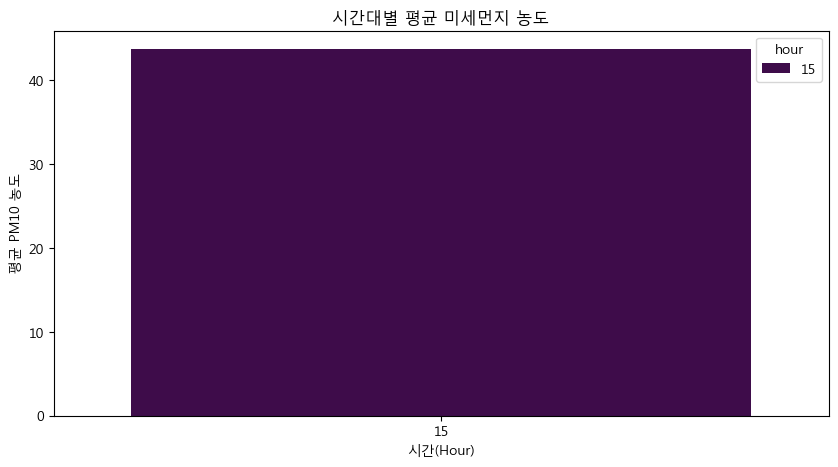

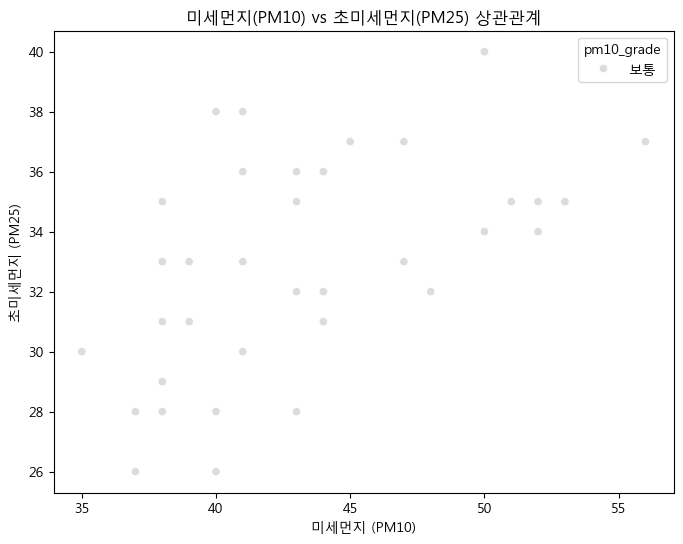

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 시각화 1: 특정 측정소의 시간별 미세먼지 추이 (Line Plot)
target_station = df['stationName'].iloc[0] # 첫 번째 측정소 기준
df_station = df[df['stationName'] == target_station]

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_station, x='dataTime', y='pm10Value', label='PM10(미세먼지)', marker='o')
sns.lineplot(data=df_station, x='dataTime', y='pm25Value', label='PM2.5(초미세먼지)', marker='s')
plt.title(f'{target_station} 측정소 시간별 미세먼지/초미세먼지 추이')
plt.xlabel('시간')
plt.ylabel('농도 (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 시각화 2: 서울시 전체 시간대별 평균 미세먼지 농도 (Bar Plot)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='hour', y='pm10Value', hue='hour',errorbar=None, palette='viridis')
plt.title('시간대별 평균 미세먼지 농도')
plt.xlabel('시간(Hour)')
plt.ylabel('평균 PM10 농도')
plt.show()

# 시각화 3: 미세먼지와 초미세먼지의 상관관계 (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pm10Value', y='pm25Value', hue='pm10_grade', palette='coolwarm')
plt.title('미세먼지(PM10) vs 초미세먼지(PM25) 상관관계')
plt.xlabel('미세먼지 (PM10)')
plt.ylabel('초미세먼지 (PM25)')
plt.show()

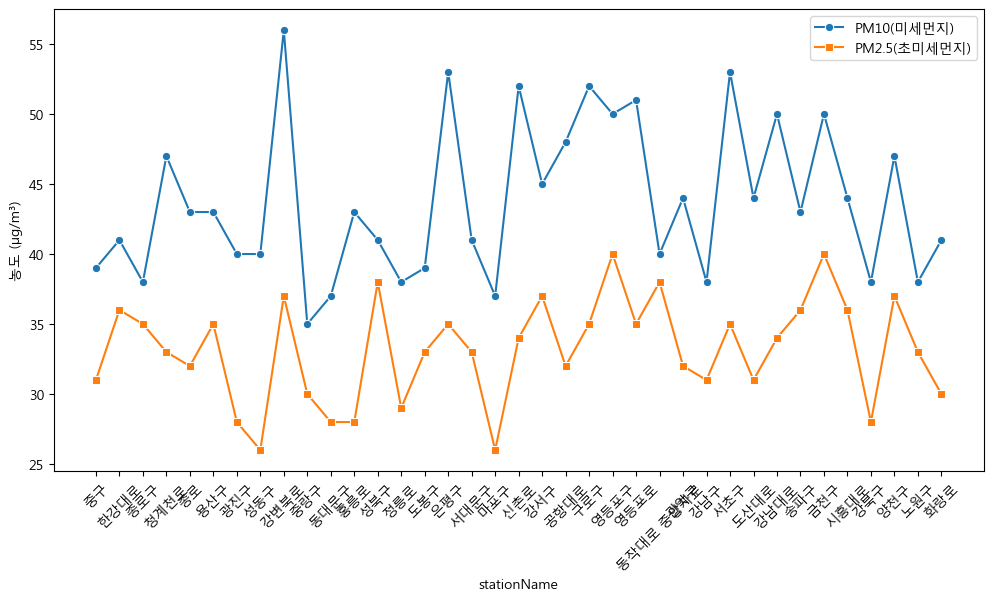

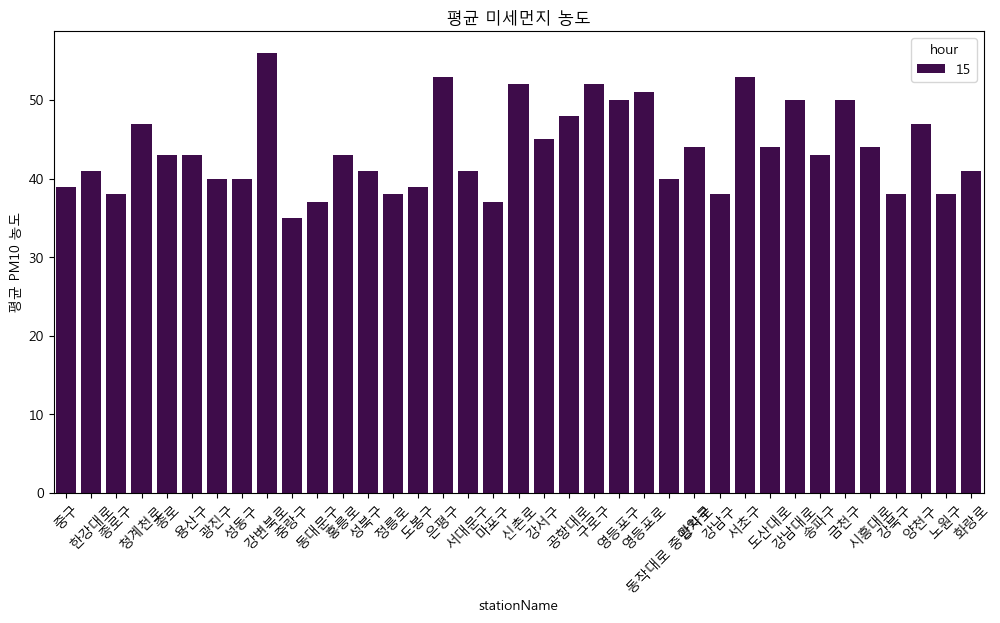

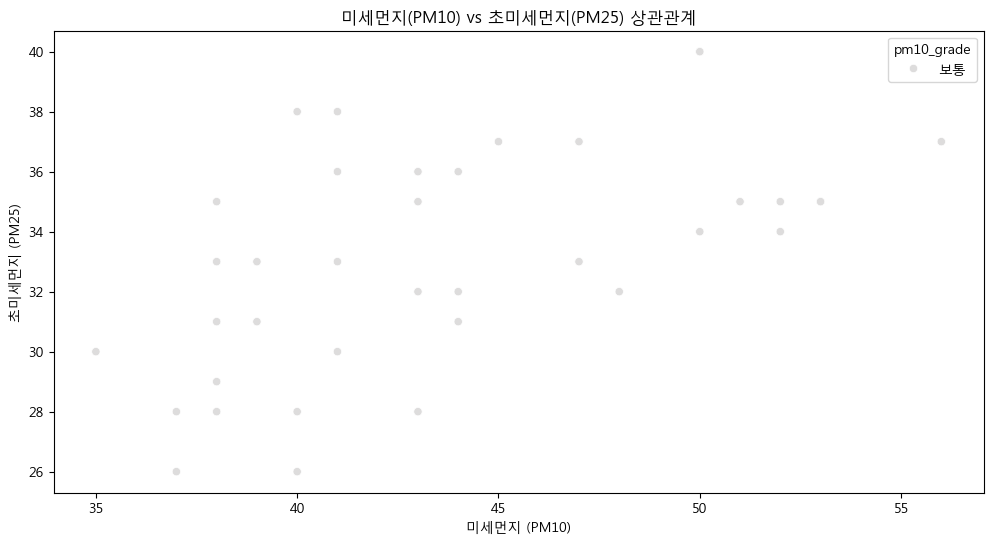

In [77]:
# 시각화 1: 특정 측정소의 시간별 미세먼지 추이 (Line Plot)
# target_station = df['stationName'].iloc[0] # 첫 번째 측정소 기준
# df_station = df[df['stationName'] == target_station]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='stationName', y='pm10Value', label='PM10(미세먼지)', marker='o')
sns.lineplot(data=df, x='stationName', y='pm25Value', label='PM2.5(초미세먼지)', marker='s')
# plt.title(f'{target_station} 측정소 시간별 미세먼지/초미세먼지 추이')
plt.xlabel('stationName')
plt.ylabel('농도 (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 시각화 2: 서울시 전체 시간대별 평균 미세먼지 농도 (Bar Plot)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='stationName', y='pm10Value', hue='hour',errorbar=None, palette='viridis')
plt.title('평균 미세먼지 농도')
plt.xlabel('stationName')
plt.ylabel('평균 PM10 농도')
plt.xticks(rotation=45)
plt.show()

# 시각화 3: 미세먼지와 초미세먼지의 상관관계 (Scatter Plot)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='pm10Value', y='pm25Value', hue='pm10_grade', palette='coolwarm')
plt.title('미세먼지(PM10) vs 초미세먼지(PM25) 상관관계')
plt.xlabel('미세먼지 (PM10)')
plt.ylabel('초미세먼지 (PM25)')
plt.show()